# 🔍 Notebook 1: Exploratory Data Analysis (EDA)

**Goal:** Understand the UNSW-NB15 dataset before touching the model.
We want to answer:
- What does the data look like?
- How imbalanced is normal vs. attack traffic?
- Which features differ most between benign and malicious traffic?
- Are there missing values or anomalies we need to handle?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

import warnings
warnings.filterwarnings("ignore")

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# Load both splits
train_df = pd.read_csv("../data/UNSW_NB15_training-set.csv")
test_df  = pd.read_csv("../data/UNSW_NB15_testing-set.csv")

# Combine for full EDA picture
df = pd.concat([train_df, test_df], ignore_index=True)

print(f"Training set : {train_df.shape}")
print(f"Testing set  : {test_df.shape}")
print(f"Full dataset : {df.shape}")


Training set : (82332, 45)
Testing set  : (175341, 45)
Full dataset : (257673, 45)


## 1. Basic Structure

In [3]:
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 257673 non-null  int64  
 1   dur                257673 non-null  float64
 2   proto              257673 non-null  str    
 3   service            257673 non-null  str    
 4   state              257673 non-null  str    
 5   spkts              257673 non-null  int64  
 6   dpkts              257673 non-null  int64  
 7   sbytes             257673 non-null  int64  
 8   dbytes             257673 non-null  int64  
 9   rate               257673 non-null  float64
 10  sttl               257673 non-null  int64  
 11  dttl               257673 non-null  int64  
 12  sload              257673 non-null  float64
 13  dload              257673 non-null  float64
 14  sloss              257673 non-null  int64  
 15  dloss              257673 non-null  int64  
 16  sinpkt       

In [5]:
# Check dtypes breakdown
dtype_counts = df.dtypes.value_counts()
print("Column data types:")
print(dtype_counts)

print(f"\nNumerical columns : {len(df.select_dtypes(include='number').columns)}")
print(f"Categorical columns : {len(df.select_dtypes(include='object').columns)}")


Column data types:
int64      30
float64    11
str         4
Name: count, dtype: int64

Numerical columns : 41
Categorical columns : 4


## 2. Missing Values & Duplicates


In [6]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count" : missing,
    "Missing %" : missing_pct
}).query("`Missing Count` > 0").sort_values("Missing %", ascending=False)

if missing_report.empty:
    print("✅ No missing values found!")
else:
    print(missing_report)

✅ No missing values found!


In [7]:
# Duplicates
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes} ({dupes/len(df)*100:.2f}%)")

Duplicate rows: 0 (0.00%)


## 3. Target Distribution — Normal vs. Attack


             Count  Percentage
Benign (0)  164673       63.91
Attack (1)   93000       36.09


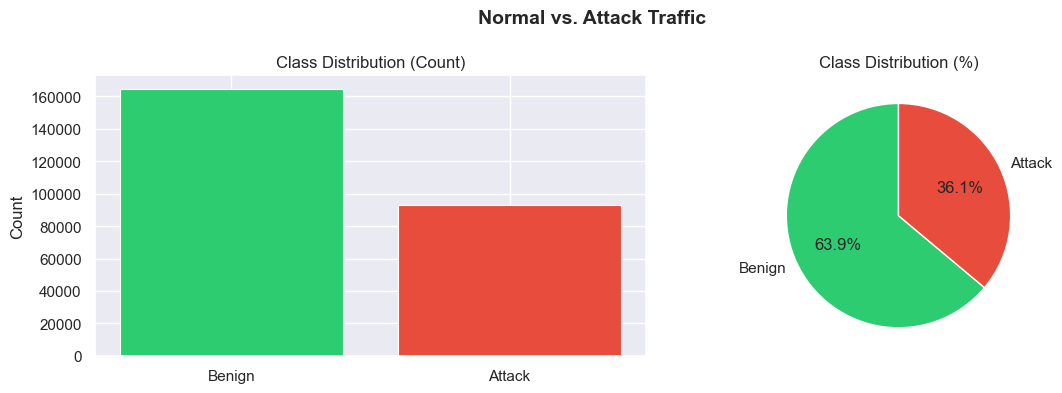

✅ Saved to outputs/figures/


In [8]:
label_counts = df["label"].value_counts()
label_pct    = df["label"].value_counts(normalize=True) * 100

label_summary = pd.DataFrame({
    "Count"      : label_counts,
    "Percentage" : label_pct.round(2)
})
label_summary.index = ["Benign (0)", "Attack (1)"]
print(label_summary)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["Benign", "Attack"], label_counts.values,
            color=["#2ecc71", "#e74c3c"], edgecolor="white", linewidth=0.8)
axes[0].set_title("Class Distribution (Count)")
axes[0].set_ylabel("Count")

axes[1].pie(label_counts.values, labels=["Benign", "Attack"],
            colors=["#2ecc71", "#e74c3c"], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Class Distribution (%)")

plt.suptitle("Normal vs. Attack Traffic", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved to outputs/figures/")

## 4. Attack Category Breakdown


attack_cat
Normal            93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174
Name: count, dtype: int64


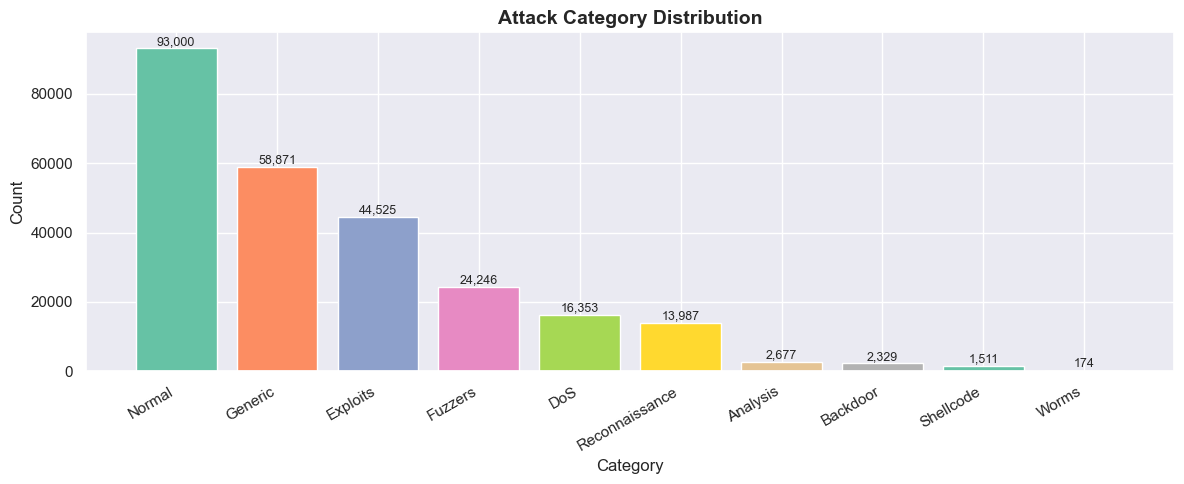

In [9]:
attack_counts = df["attack_cat"].value_counts()
print(attack_counts)

plt.figure(figsize=(12, 5))
bars = plt.bar(attack_counts.index, attack_counts.values,
               color=sns.color_palette("Set2", len(attack_counts)),
               edgecolor="white")

plt.title("Attack Category Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")

for bar, val in zip(bars, attack_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f"{val:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/01_attack_categories.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Feature Distributions — Normal vs. Attack
Comparing the top numerical features between benign and attack traffic.

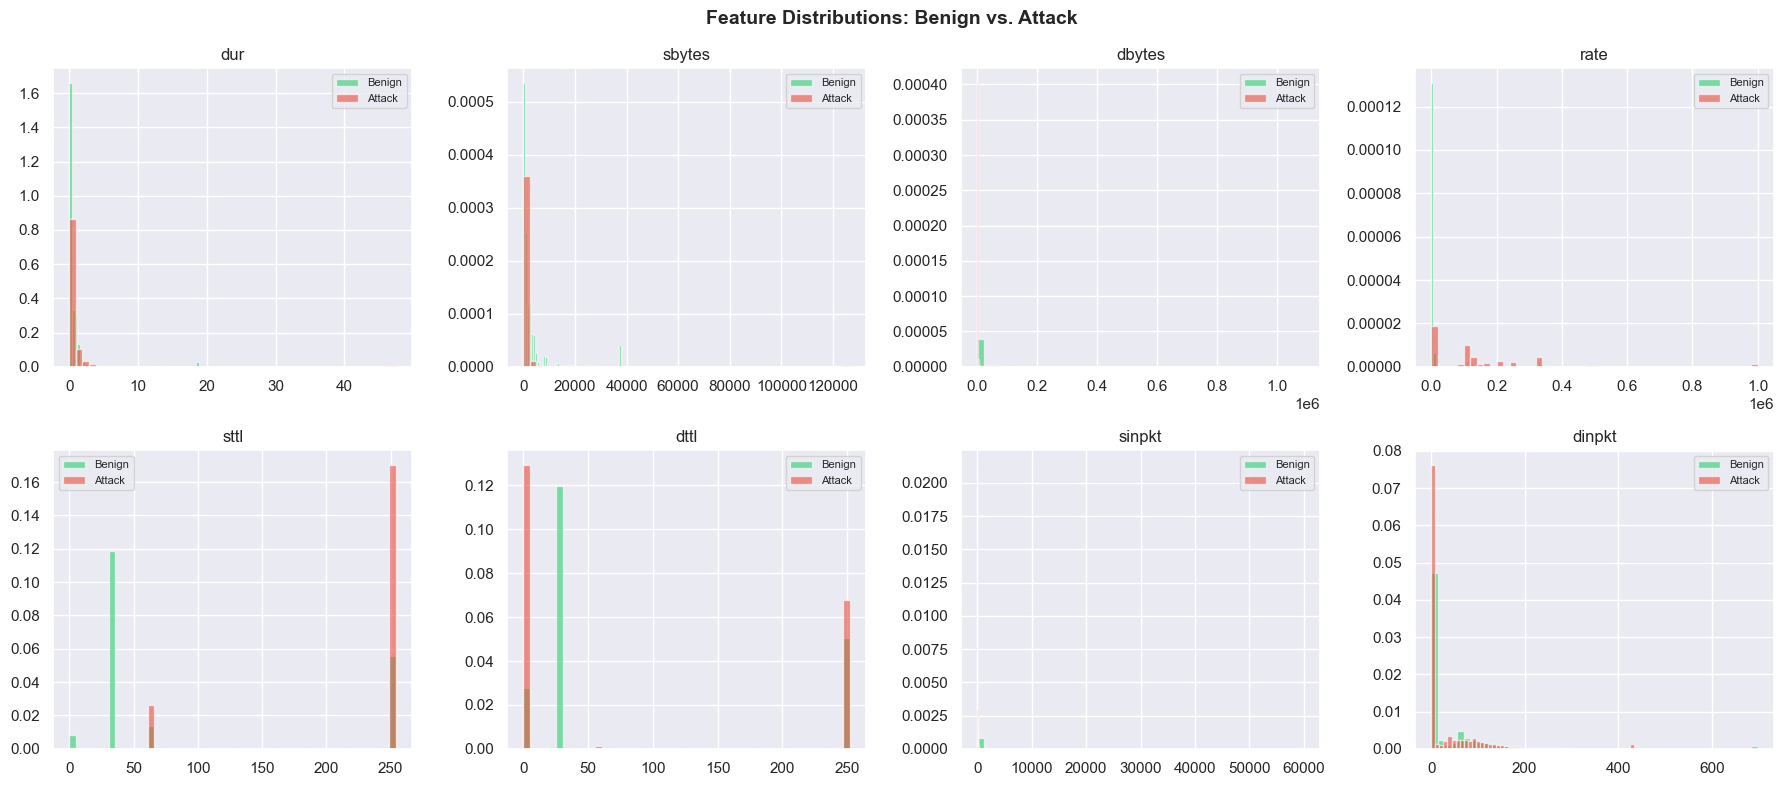

In [13]:
# Top features to inspect (using actual column names)
key_features = ["dur", "sbytes", "dbytes", "rate",
                "sttl", "dttl", "sinpkt", "dinpkt"]

benign = df[df["label"] == 0]
attack = df[df["label"] == 1]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    axes[i].hist(benign[feat].clip(upper=benign[feat].quantile(0.99)),
                 bins=50, alpha=0.6, color="#2ecc71", label="Benign", density=True)
    axes[i].hist(attack[feat].clip(upper=attack[feat].quantile(0.99)),
                 bins=50, alpha=0.6, color="#e74c3c", label="Attack", density=True)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel("")

plt.suptitle("Feature Distributions: Benign vs. Attack", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/01_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Correlation Heatmap (Numerical Features)

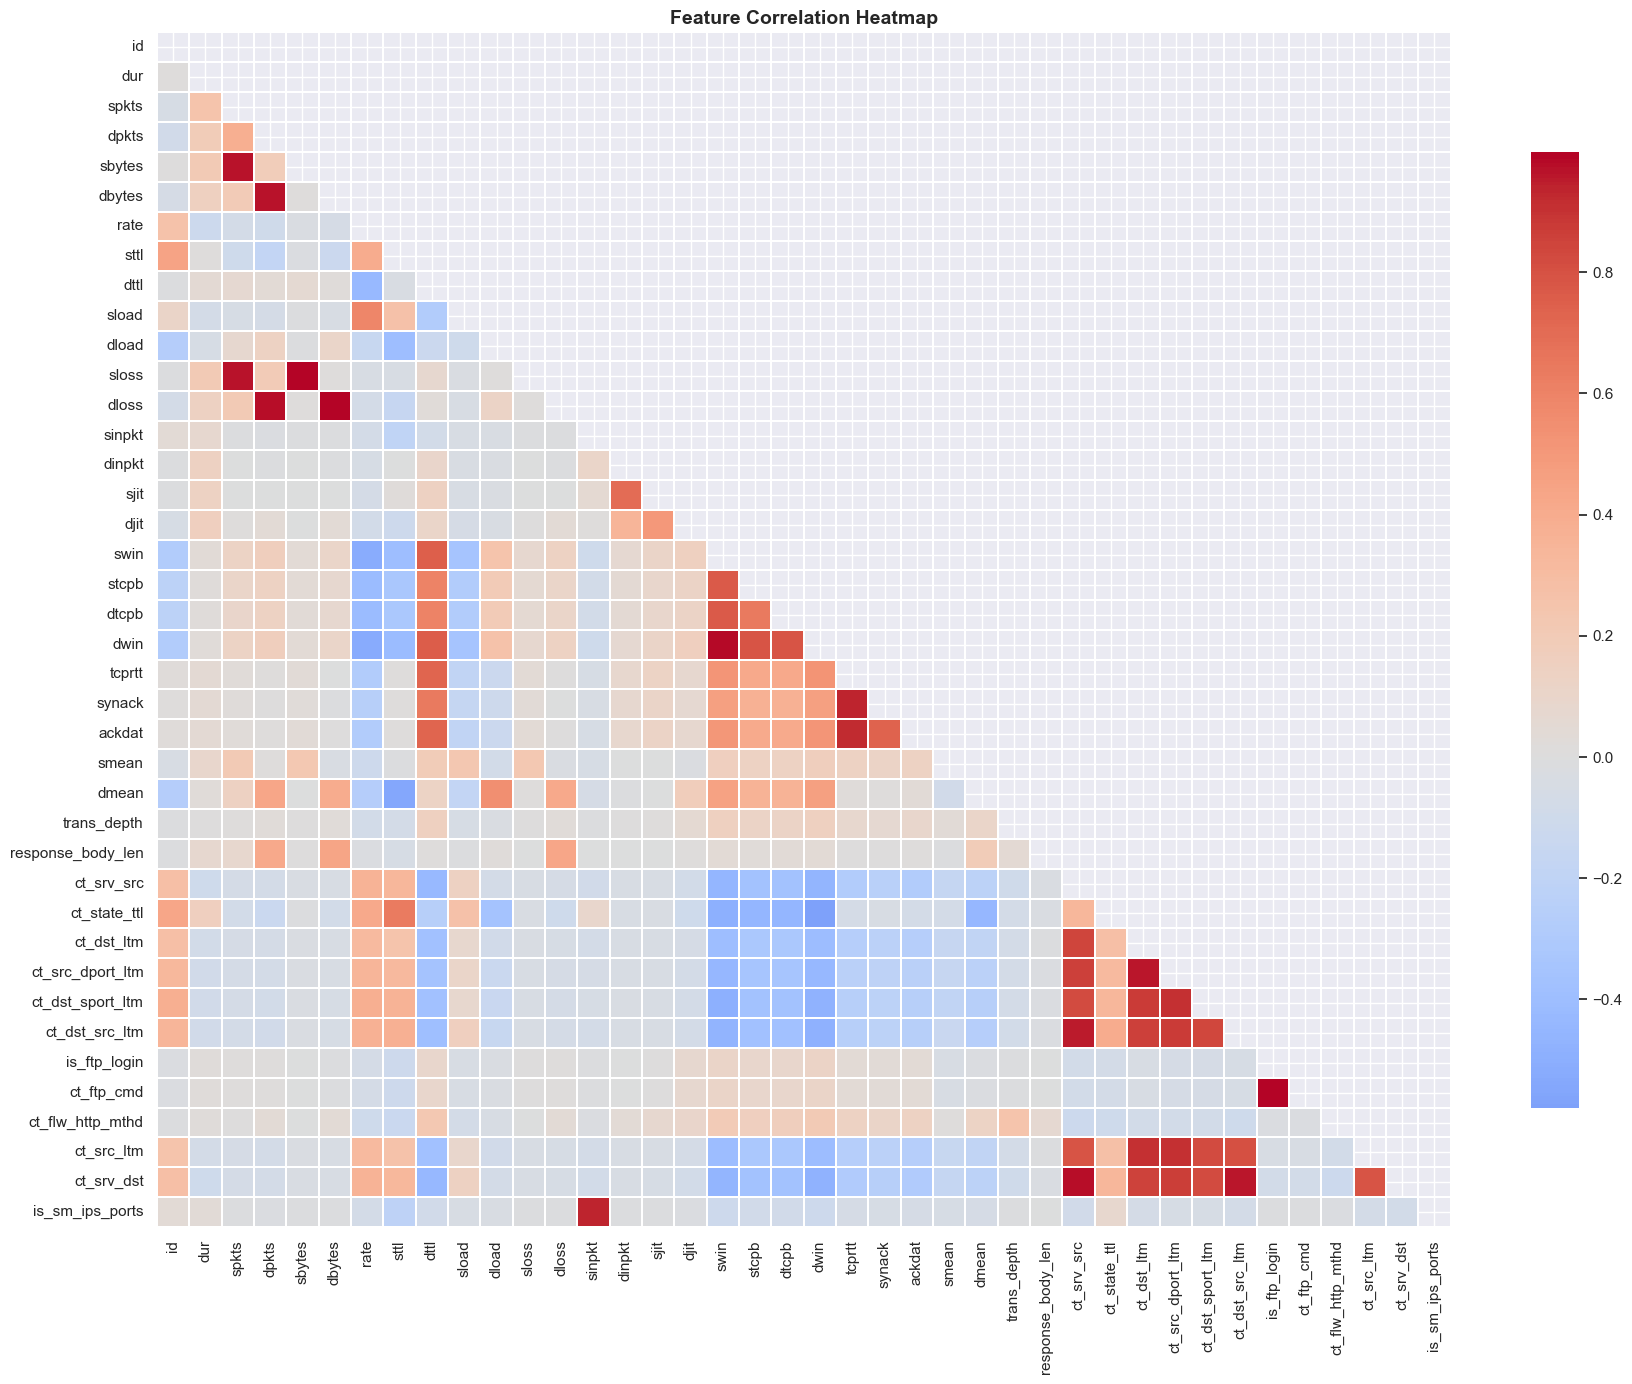

In [14]:
# Select numerical columns only (excluding label)
num_cols = df.select_dtypes(include="number").columns.drop("label").tolist()

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, fmt=".1f",
            cmap="coolwarm", center=0, linewidths=0.3,
            cbar_kws={"shrink": 0.8})

plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/01_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Categorical Features Overview

In [15]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols = [c for c in cat_cols if c != "attack_cat"]
print(f"Categorical columns: {cat_cols}\n")

for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique values → {df[col].unique()[:10]}")

Categorical columns: ['proto', 'service', 'state']

  proto: 133 unique values → <StringArray>
['udp', 'arp', 'tcp', 'igmp', 'ospf', 'sctp', 'gre', 'ggp', 'ip', 'ipnip']
Length: 10, dtype: str
  service: 13 unique values → <StringArray>
['-', 'http', 'ftp', 'ftp-data', 'smtp', 'pop3', 'dns', 'snmp', 'ssl', 'dhcp']
Length: 10, dtype: str
  state: 11 unique values → <StringArray>
['INT', 'FIN', 'REQ', 'ACC', 'CON', 'RST', 'CLO', 'ECO', 'PAR', 'URN']
Length: 10, dtype: str


## 8. Key Findings Summary

In [16]:
print("=" * 50)
print("       EDA SUMMARY — UNSW-NB15 Dataset")
print("=" * 50)
print(f"  Total records        : {len(df):,}")
print(f"  Total features       : {df.shape[1] - 2}  (excl. label & attack_cat)")
print(f"  Benign traffic       : {label_counts[0]:,} ({label_counts[0]/len(df)*100:.1f}%)")
print(f"  Attack traffic       : {label_counts[1]:,} ({label_counts[1]/len(df)*100:.1f}%)")
print(f"  Attack categories    : {df['attack_cat'].nunique()}")
print(f"  Missing values       : {df.isnull().sum().sum()}")
print(f"  Duplicate rows       : {df.duplicated().sum()}")
print(f"  Numerical features   : {len(df.select_dtypes(include='number').columns) - 1}")
print(f"  Categorical features : {len(df.select_dtypes(include='object').columns)}")
print("=" * 50)

       EDA SUMMARY — UNSW-NB15 Dataset
  Total records        : 257,673
  Total features       : 43  (excl. label & attack_cat)
  Benign traffic       : 93,000 (36.1%)
  Attack traffic       : 164,673 (63.9%)
  Attack categories    : 10
  Missing values       : 0
  Duplicate rows       : 0
  Numerical features   : 40
  Categorical features : 4
